# Debug: Synthetic Spectra

Check that `generate_spectrum` and `SyntheticSpectraDataset` work as expected:
- K distribution (uniform 0..Kmax?)
- Spectra look plausible (no NaNs, sane shapes)
- Determinism (same seed → same spectrum)
- Parameter space coverage (noise, baseline, variety of K)


In [ ]:
# Assumes: pip install -e . from project root

In [54]:
import numpy as np
import matplotlib.pyplot as plt
from spectackle.data import BASE_CFG, generate_spectrum, SyntheticSpectraDataset

In [55]:
### Config
### Force p_zero=0.10 so K=0 is well-represented (avoids cached-import issues)
from spectackle.config import deep_update
cfg = deep_update(BASE_CFG, {"gen": {"p_zero": 0.10}})
Kmax = int(cfg["max_components"])
n_channels = int(cfg["n_channels"])
print(f"Kmax={Kmax}, n_channels={n_channels}, p_zero={cfg['gen']['p_zero']}")

Kmax=10, n_channels=256


In [ ]:
### check shapes, no NaN, determinism

rng = np.random.default_rng(42)
ex = generate_spectrum(cfg, rng=rng)

assert ex["spec"].shape == (n_channels,), f"spec shape: {ex['spec'].shape}"
assert ex["spec_clean"].shape == (n_channels,)
assert 0 <= ex["k"] <= Kmax, f"k={ex['k']} outside [0, {Kmax}]"
assert not np.any(np.isnan(ex["spec"])), "NaN in spec"
assert not np.any(np.isinf(ex["spec"])), "Inf in spec"

rng2 = np.random.default_rng(42)
ex2 = generate_spectrum(cfg, rng=rng2)
assert np.allclose(ex["spec"], ex2["spec"]), "Same seed should give same spectrum"

print("Test OK: shapes, no NaN/Inf, deterministic")

Sanity OK: shapes, no NaN/Inf, deterministic


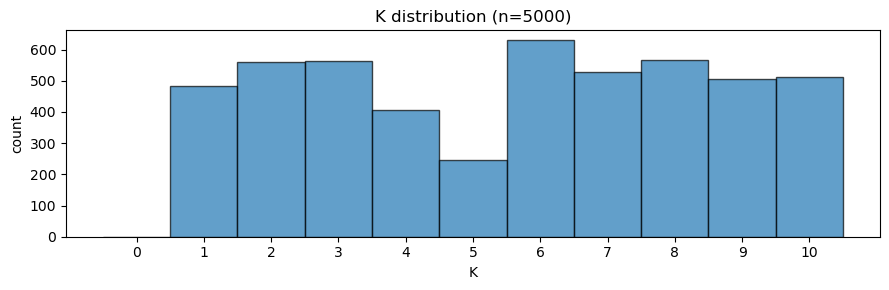

Expected ~455 per K. Min=0, max=630


In [57]:
### K distribution over N samples (should be ~uniform 0..Kmax)

N = 5000
rng = np.random.default_rng(0)
ks = [generate_spectrum(cfg, rng=rng)["k"] for _ in range(N)]
ks = np.array(ks)

fig, ax = plt.subplots(figsize=(9, 3))
ax.hist(ks, bins=np.arange(-0.5, Kmax + 1.5, 1), edgecolor="k", alpha=0.7)
ax.set_xlabel("K")
ax.set_ylabel("count")
ax.set_title(f"K distribution (n={N})")
ax.set_xticks(np.arange(0, Kmax + 1))
plt.tight_layout()
plt.show()

counts_per_k = np.array([(ks == k).sum() for k in range(Kmax + 1)])
expected = N / (Kmax + 1)
print(f"Expected ~{expected:.0f} per K. Min={counts_per_k.min()}, max={counts_per_k.max()}")

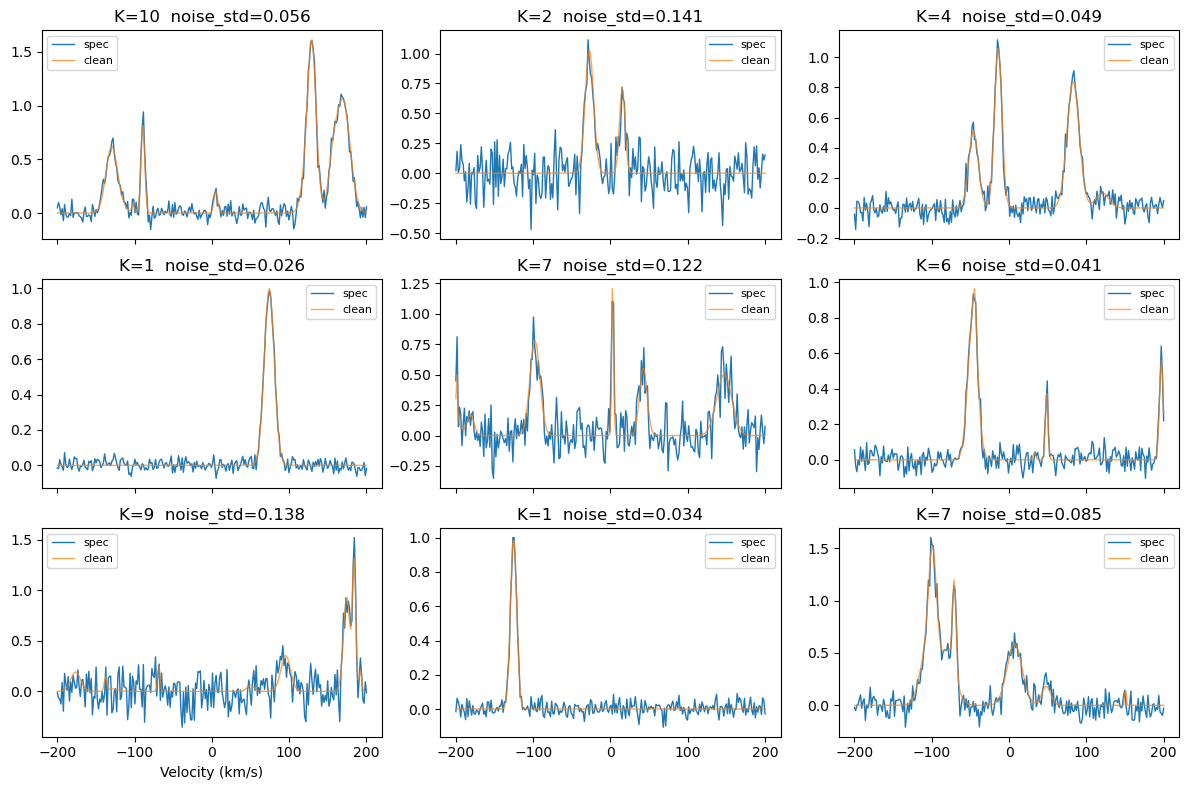

In [58]:
### Example spectra: random sample (various K)

rng = np.random.default_rng(123)
examples = [generate_spectrum(cfg, rng=rng) for _ in range(9)]

fig, axes = plt.subplots(3, 3, figsize=(12, 8), sharex=True)
v = examples[0]["v_axis"]
for ax, ex in zip(axes.flat, examples):
    ax.plot(v, ex["spec"], lw=1, label="spec")
    ax.plot(v, ex["spec_clean"], lw=1, alpha=0.7, label="clean")
    ax.set_title(f"K={ex['k']}  noise_std={ex['noise_std'][0]:.3f}")
    ax.legend(fontsize=8)
axes[-1, 0].set_xlabel("Velocity (km/s)")
plt.tight_layout()
plt.show()

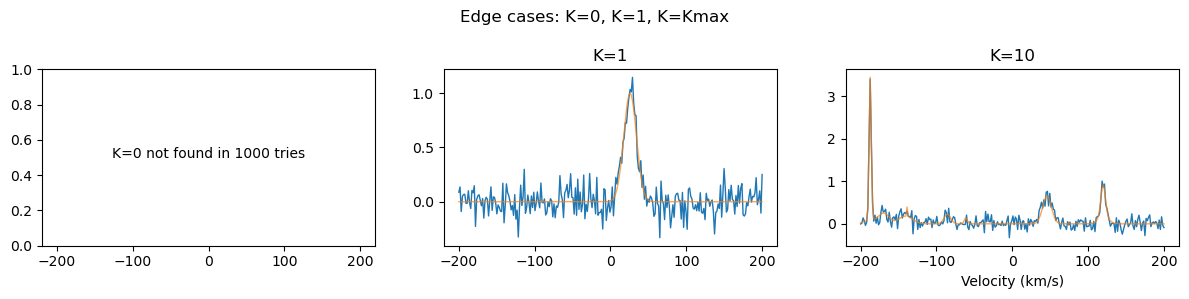

In [59]:
### Edge cases: hunt for K=0, K=1, K=Kmax
### With p_zero=0.10, K=0 should be found quickly; max_tries=5000 for robustness

def find_k(rng, target_k, max_tries=5000):
    for _ in range(max_tries):
        ex = generate_spectrum(cfg, rng=rng)
        if ex["k"] == target_k:
            return ex
    return None

rng = np.random.default_rng(999)
fig, axes = plt.subplots(1, 3, figsize=(12, 3), sharex=True)

for ax, k_target in zip(axes, [0, 1, Kmax]):
    ex = find_k(rng, k_target)
    if ex is None:
        ax.text(0.5, 0.5, f"K={k_target} not found in 5000 tries", ha="center", transform=ax.transAxes)
    else:
        v = ex["v_axis"]
        ax.plot(v, ex["spec"], lw=1)
        ax.plot(v, ex["spec_clean"], lw=1, alpha=0.7)
        ax.set_title(f"K={k_target}")
ax.set_xlabel("Velocity (km/s)")
plt.suptitle("Edge cases: K=0, K=1, K=Kmax")
plt.tight_layout()
plt.show()

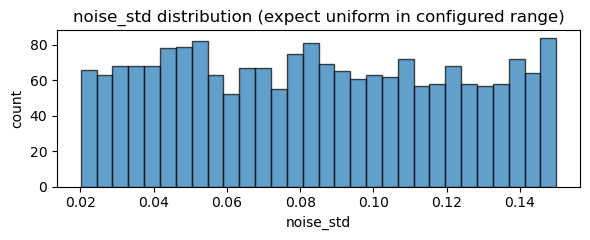

In [60]:
### Noise and baseline: distribution of noise_std

N = 2000
rng = np.random.default_rng(7)
noise_stds = [generate_spectrum(cfg, rng=rng)["noise_std"][0] for _ in range(N)]

plt.figure(figsize=(6, 2.5))
plt.hist(noise_stds, bins=30, edgecolor="k", alpha=0.7)
plt.xlabel("noise_std")
plt.ylabel("count")
plt.title("noise_std distribution (expect uniform in configured range)")
plt.tight_layout()
plt.show()

In [61]:
### Dataset: shapes and K range

ds = SyntheticSpectraDataset(cfg, n_samples=1000, base_seed=0)
sample = ds[0]

assert sample["spec"].shape == (n_channels,)
assert sample["K_true"].shape == (1,)

ks_ds = np.array([ds[i]["K_true"].item() for i in range(len(ds))])
print(f"Dataset K range: [{ks_ds.min()}, {ks_ds.max()}]")
print(f"Dataset K mean: {ks_ds.mean():.2f}")

Dataset K range: [1, 10]
Dataset K mean: 5.52
